# Modeling Comparison
 generates a combined model comparison table and plot, and shows overfitting gaps and best-model selection.


In [33]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

results_dir = Path("modeling_results")
performance = pd.read_csv(results_dir / "model_performance_summary.csv")
classification_reports = json.loads((results_dir / "classification_reports.json").read_text())

test_metrics = performance[performance["split"] == "test"].set_index("model")
comparison_path = results_dir / "modeling_comparison_summary.csv"
comparison_df = test_metrics.copy()
comparison_df["train_val_gap"] = (
    performance[performance["split"] == "train"].set_index("model")["accuracy"]
    - performance[performance["split"] == "validation"].set_index("model")["accuracy"]
)
comparison_df["val_test_gap"] = (
    performance[performance["split"] == "validation"].set_index("model")["accuracy"]
    - performance[performance["split"] == "test"].set_index("model")["accuracy"]
)
comparison_df.to_csv(comparison_path)

print("Combined test metrics and gap table saved to:")
print(comparison_path)
display(comparison_df)


Combined test metrics and gap table saved to:
modeling_results\modeling_comparison_summary.csv


,split,accuracy,precision,recall,f1,roc_auc,train_val_gap,val_test_gap
model,,,,,,,,
logistic_regression,test,0.885870,0.878505,0.921569,0.899522,0.920732,0.066581,-0.076087
random_forest,test,0.836957,0.839623,0.872549,0.855769,0.920134,0.093893,-0.016304
xgboost,test,0.880435,0.870370,0.921569,0.895238,0.923840,0.070316,-0.043478


In [34]:
report_rows = []
for model_name, model_report in classification_reports.items():
    for label, label_metrics in model_report.items():
        if label in ["0", "1"]:
            report_rows.append(
                {
                    "model": model_name,
                    "label": label,
                    "precision": label_metrics["precision"],
                    "recall": label_metrics["recall"],
                    "f1-score": label_metrics["f1-score"],
                    "support": label_metrics["support"],
                }
            )
classification_df = pd.DataFrame(report_rows)
classification_csv = results_dir / "classification_reports_table.csv"
classification_df.to_csv(classification_csv, index=False)
print("Readable classification report saved to:")
print(classification_csv)
display(classification_df)


Readable classification report saved to:
modeling_results\classification_reports_table.csv


,model,label,precision,recall,f1-score,support
0,logistic_regression,0,0.896104,0.841463,0.867925,82.0
1,logistic_regression,1,0.878505,0.921569,0.899522,102.0
2,random_forest,0,0.833333,0.792683,0.812500,82.0
3,random_forest,1,0.839623,0.872549,0.855769,102.0
4,xgboost,0,0.894737,0.829268,0.860759,82.0
5,xgboost,1,0.870370,0.921569,0.895238,102.0



Generalization gaps


,train_val_gap,val_test_gap
model,,
logistic_regression,0.066581,-0.076087
random_forest,0.093893,-0.016304
xgboost,0.070316,-0.043478


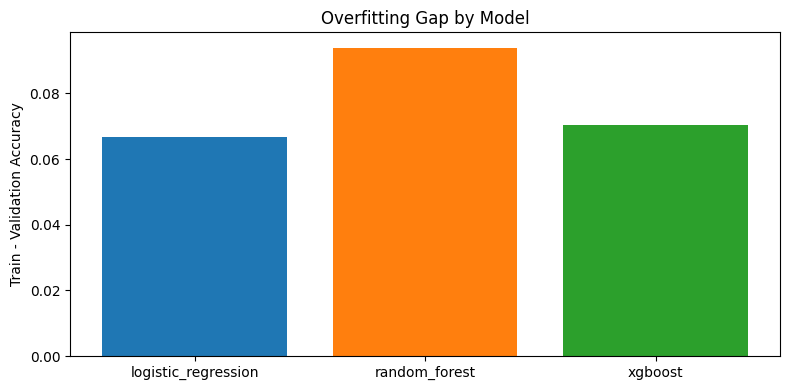

Best model by test ROC AUC: xgboost
split            test
accuracy     0.880435
precision     0.87037
recall       0.921569
f1           0.895238
roc_auc       0.92384
Name: xgboost, dtype: object


In [35]:
print("\nGeneralization gaps")
display(comparison_df[["train_val_gap", "val_test_gap"]])

plt.figure(figsize=(8, 4))
plt.bar(comparison_df.index, comparison_df["train_val_gap"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.ylabel("Train - Validation Accuracy")
plt.title("Overfitting Gap by Model")
plt.tight_layout()
plt.show()

best_model = comparison_df["roc_auc"].idxmax()
print(f"Best model by test ROC AUC: {best_model}")
print(test_metrics.loc[best_model])


In [36]:
rank_df = test_metrics.copy()
rank_df["combined_score"] = (
    0.4 * rank_df["roc_auc"] +
    0.35 * rank_df["f1"] +
    0.25 * rank_df["accuracy"]
)
rank_df = rank_df.sort_values("combined_score", ascending=False)

print("Model ranking by combined score")
display(rank_df[["accuracy", "precision", "recall", "f1", "roc_auc", "combined_score"]])

if "xgboost" in rank_df.index and "random_forest" in rank_df.index:
    diff = rank_df.loc["xgboost", ["accuracy", "precision", "recall", "f1", "roc_auc"]] - rank_df.loc["random_forest", ["accuracy", "precision", "recall", "f1", "roc_auc"]]
    print("\nXGBoost minus Random Forest on test metrics:")
    print(diff)


Model ranking by combined score


,accuracy,precision,recall,f1,roc_auc,combined_score
model,,,,,,
logistic_regression,0.885870,0.878505,0.921569,0.899522,0.920732,0.904593
xgboost,0.880435,0.870370,0.921569,0.895238,0.923840,0.902978
random_forest,0.836957,0.839623,0.872549,0.855769,0.920134,0.876812



XGBoost minus Random Forest on test metrics:
accuracy     0.043478
precision    0.030748
recall       0.049020
f1           0.039469
roc_auc      0.003706
dtype: float64


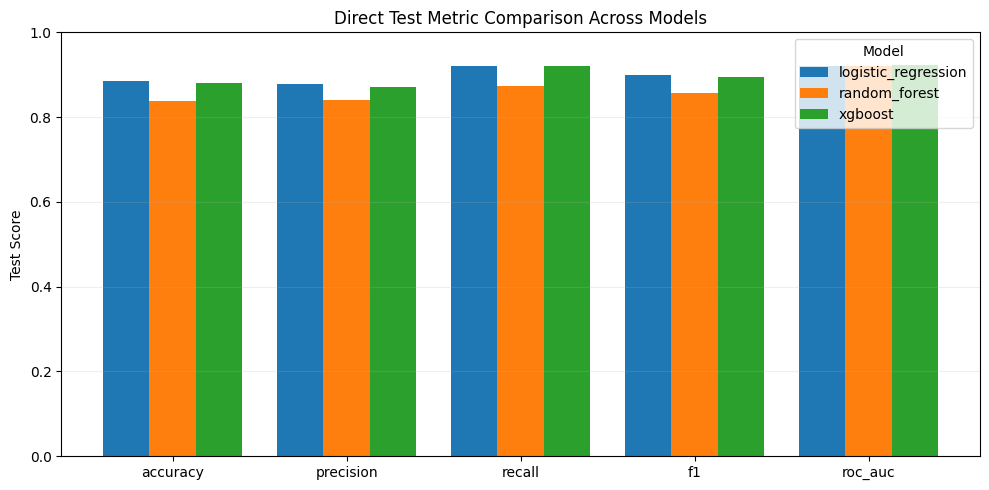

In [37]:
import numpy as np

metrics_to_compare = ["accuracy", "precision", "recall", "f1", "roc_auc"]
group_df = test_metrics[metrics_to_compare]
models = group_df.index.tolist()

x = np.arange(len(metrics_to_compare))
width = 0.8 / max(len(models), 1)

plt.figure(figsize=(10, 5))
for idx, model in enumerate(models):
    plt.bar(x + idx * width, group_df.loc[model], width, label=model)

plt.xticks(x + width * (len(models) - 1) / 2, metrics_to_compare)
plt.ylim(0, 1.0)
plt.ylabel("Test Score")
plt.title("Direct Test Metric Comparison Across Models")
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

C:\Users\jakec\AppData\Local\Temp\ipykernel_35468\2437772079.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 0.95])


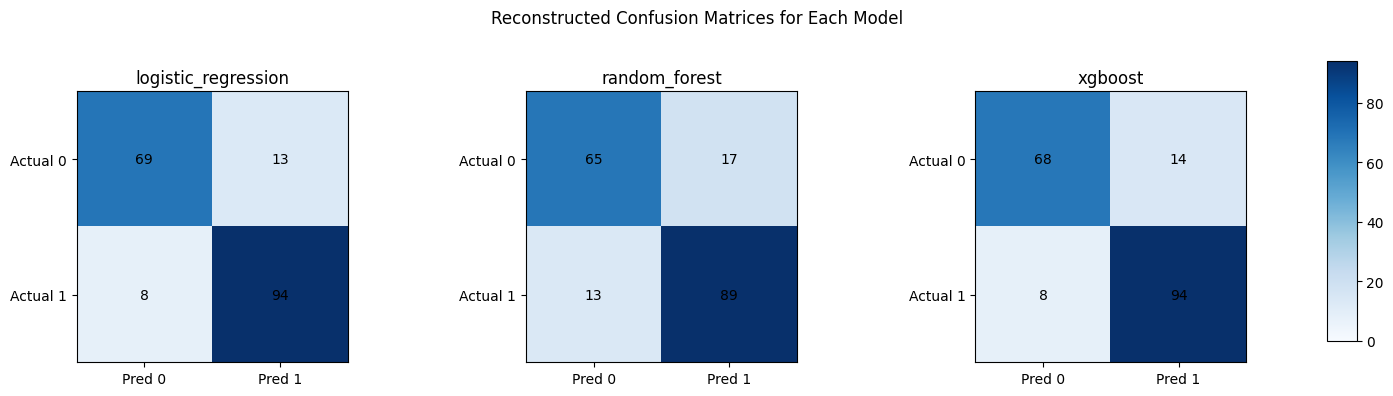

In [41]:
import numpy as np
import matplotlib.pyplot as plt

confusion_results = []
for model_name, model_report in classification_reports.items():
    if "0" in model_report and "1" in model_report:
        tn = model_report["0"]["recall"] * model_report["0"]["support"]
        tp = model_report["1"]["recall"] * model_report["1"]["support"]
        fn = model_report["1"]["support"] - tp
        fp = model_report["0"]["support"] - tn
        cm = np.array([[tn, fp], [fn, tp]], dtype=int)
        confusion_results.append((model_name, cm))

if confusion_results:
    fig, axes = plt.subplots(1, len(confusion_results), figsize=(5 * len(confusion_results), 4))
    if len(confusion_results) == 1:
        axes = [axes]
    for ax, (model_name, cm) in zip(axes, confusion_results):
        im = ax.imshow(cm, cmap="Blues", vmin=0)
        ax.set_title(model_name)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticklabels(["Actual 0", "Actual 1"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cax)
    plt.suptitle("Reconstructed Confusion Matrices for Each Model")
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])
    plt.show()
else:
    print("No binary classification report data available to reconstruct confusion matrices.")